## AI-Powered Audit & Fraud Detection System

Project Description:

This project presents an advanced Audit Analytics and Fraud Detection framework using Machine Learning and Explainable AI techniques. The objective is to identify high-risk or fraudulent transactions within highly imbalanced financial datasets while maintaining transparency and interpretability of model decisions.

The system was developed using Python and modern data science methodologies, integrating predictive analytics with Explainable Artificial Intelligence (XAI) approaches such as SHAP, LIME, and Permutation Feature Importance (PFI).

The model demonstrates strong classification performance on a large-scale dataset with over 280,000 records and 30 analytical features.

Key Objectives:

Detect anomalous or fraudulent transactions
Support Internal Audit and Risk Management processes
Improve risk-based auditing using AI
Enhance transparency of machine learning decisions
Reduce false negatives in fraud detection
Provide explainable and auditable AI outputs

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

from sklearn.inspection import permutation_importance

from IPython.display import display



In [4]:
# load data
df = pd.read_csv("creditcard.csv")

# Show first 5 rows
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [6]:
print("\nTarget Classes:")
print(df["Class"].value_counts())

print("\nFraud Ratio:")
print(df["Class"].value_counts(normalize=True))



Target Classes:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Ratio:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [7]:


# 3. DEFINE FEATURES & TARGET


X = df.drop("Class", axis=1)
y = df["Class"]


In [8]:

# 4. TRAIN / TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)



Training Shape: (227845, 30)
Testing Shape: (56962, 30)


In [12]:

# 5. BUILD AUDIT-READY PIPELINE

# Why Pipeline?
# - Reproducibility
# - Governance
# - Audit traceability
# - Cleaner deployment structure

audit_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="median")),
    
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


In [13]:

# 6. TRAIN MODEL


print("\nTraining Random Forest Model...")

audit_pipeline.fit(X_train, y_train)

print("Model Training Completed.")




Training Random Forest Model...
Model Training Completed.


In [14]:
# =========================
# 7. MODEL PREDICTIONS
# =========================

y_pred = audit_pipeline.predict(X_test)

y_proba = audit_pipeline.predict_proba(X_test)[:, 1]



In [15]:

# 8. MODEL EVALUATION

# Critical for fraud detection:
# - ROC-AUC
# - Precision
# - Recall
# - PR-AUC

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


roc_auc = roc_auc_score(y_test, y_proba)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

pr_auc = average_precision_score(y_test, y_proba)


print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")




MODEL PERFORMANCE

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9753
Precision Score: 0.8316
Recall Score: 0.8061
F1-Score: 0.8187
PR-AUC Score: 0.8320


In [16]:

# 9. CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)




Confusion Matrix:
[[56848    16]
 [   19    79]]


In [17]:

# 10. PERMUTATION FEATURE IMPORTANCE

# Global Explainability

print("\nCalculating Permutation Feature Importance...")

pfi_result = permutation_importance(
    audit_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

pfi_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": pfi_result.importances_mean
})

pfi_df = pfi_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Global Important Features:")
display(pfi_df.head(15))



Calculating Permutation Feature Importance...

Top Global Important Features:


,Feature,Importance
12,V12,0.000839
3,V3,0.000509
4,V4,0.000404
11,V11,0.000316
14,V14,0.000288
10,V10,0.000260
24,V24,0.000032
15,V15,0.000028
16,V16,0.000014
28,V28,0.000004


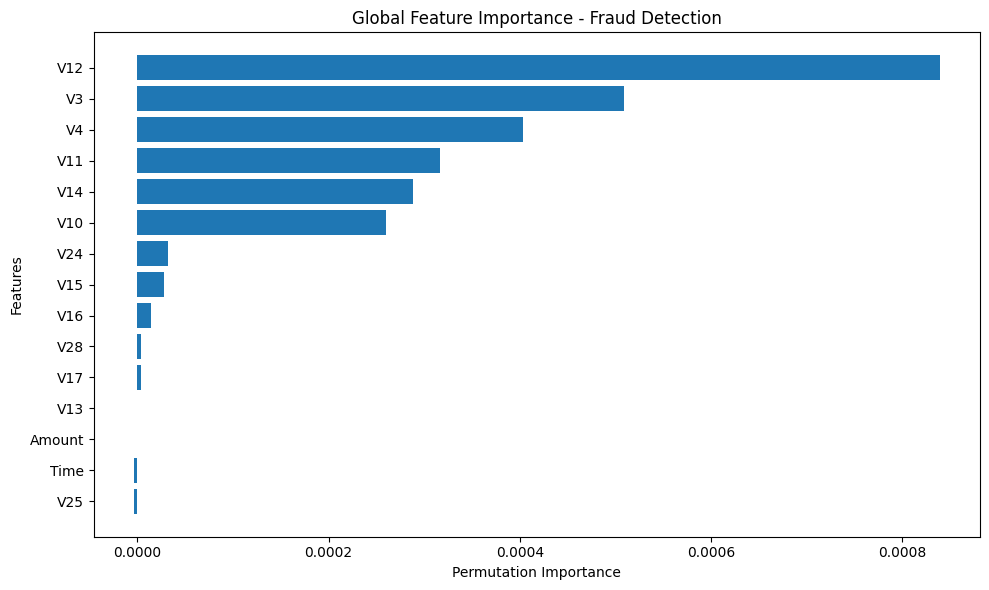

In [21]:

# 11. PFI VISUALIZATION


top_features = pfi_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Permutation Importance")

plt.ylabel("Features")

plt.title("Global Feature Importance - Fraud Detection")

plt.tight_layout()

plt.show()


In [24]:

# 12. SHAP EXPLAINABILITY


print("\nGenerating SHAP Explanations...")

# Extract trained RF model
rf_model = audit_pipeline.named_steps["model"]

# Impute test data
X_test_imputed = audit_pipeline.named_steps[
    "imputer"
].transform(X_test)

# Create DataFrame again
X_test_imputed_df = pd.DataFrame(
    X_test_imputed,
    columns=X.columns
)

# SHAP Explainer
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_imputed_df)

print("SHAP Calculation Completed.")




Generating SHAP Explanations...
SHAP Calculation Completed.


<class 'numpy.ndarray'>
ARRAY VERSION
(56962, 30, 2)
(56962, 30)

Displaying Global SHAP Summary Plot...


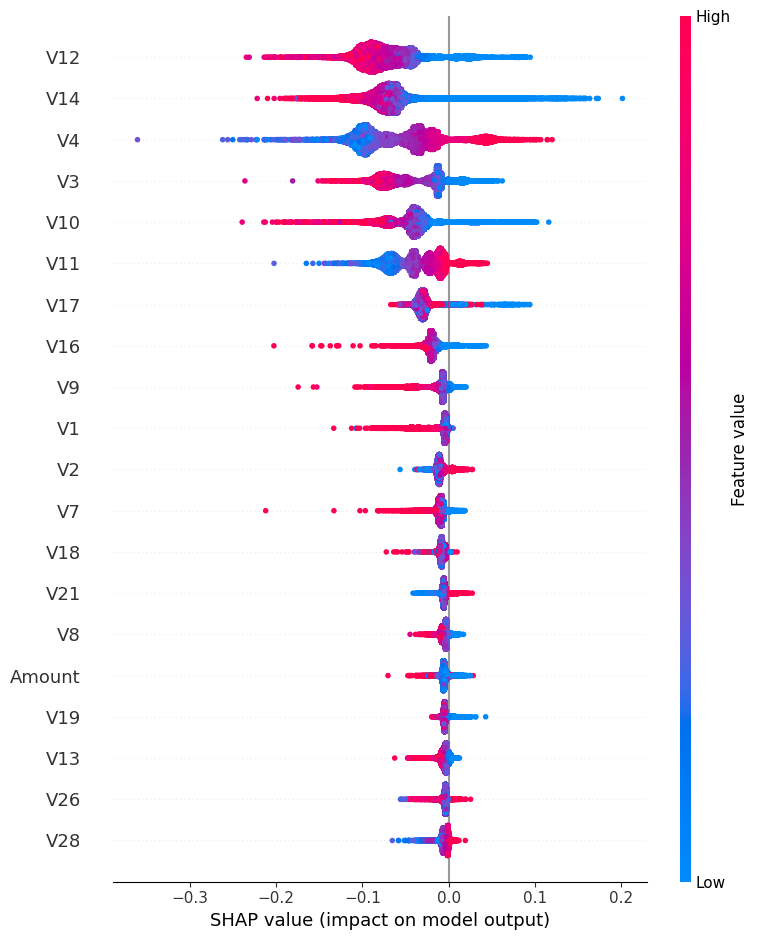

In [20]:

# 13. GLOBAL SHAP SUMMARY

print(type(shap_values))

if isinstance(shap_values, list):
    print("LIST VERSION")
    print(shap_values[0].shape)
    print(shap_values[1].shape)

else:
    print("ARRAY VERSION")
    print(shap_values.shape)

print(X_test_imputed.shape)
print("\nDisplaying Global SHAP Summary Plot...")


# CASE 1: Older SHAP versions
if isinstance(shap_values, list):

    shap.summary_plot(
        shap_values[1],
        X_test_imputed,
        feature_names=X.columns
    )

# CASE 2: Newer SHAP versions
else:

    shap.summary_plot(
        shap_values[:, :, 1],
        X_test_imputed,
        feature_names=X.columns
    )

In [21]:

# 14. LOCAL FRAUD EXPLANATION


fraud_cases = X_test[y_test == 1]

if len(fraud_cases) > 0:

    fraud_index = fraud_cases.index[0]

    fraud_instance = X_test.loc[[fraud_index]]

    fraud_instance_imputed = audit_pipeline.named_steps[
        "imputer"
    ].transform(fraud_instance)

    print("\n" + "=" * 60)
    print(f"Explaining fraud prediction for transaction {fraud_index}")
    print("=" * 60)

    predicted_probability = audit_pipeline.predict_proba(
        fraud_instance
    )[0][1]

    print(f"Predicted Fraud Probability: {predicted_probability:.4f}")

    # SHAP FORCE PLOT

    shap.initjs()

    # OLD SHAP API
    if isinstance(shap_values, list):

        local_shap_values = shap_values[1][0]
        expected_value = explainer.expected_value[1]

    # NEW SHAP API
    else:

        local_shap_values = shap_values[0, :, 1]
        expected_value = explainer.expected_value[1]

    shap.force_plot(
        expected_value,
        local_shap_values,
        fraud_instance_imputed[0],
        feature_names=X.columns
    )

else:

    print("No fraud transactions found in the test set.")


Explaining fraud prediction for transaction 77348
Predicted Fraud Probability: 0.9898


In [22]:

# 15. EXPORT AUDIT REPORTS


# Export Global Feature Importance
pfi_df.to_excel(
    "audit_global_feature_importance.xlsx",
    index=False
)

# Optional CSV export
pfi_df.to_csv(
    "audit_global_feature_importance.csv",
    index=False
)

print("PFI Reports Exported Successfully.")

PFI Reports Exported Successfully.


In [23]:
# Export predictions
prediction_report = pd.DataFrame({
    "Actual_Class": y_test,
    "Predicted_Class": y_pred,
    "Fraud_Probability": y_proba
})

prediction_report.to_excel(
    "audit_prediction_results.xlsx",
    index=False
)



In [30]:
# =========================
# 16. FINAL AUDIT CONCLUSION
# =========================

print("\n" + "=" * 60)
print("AUDIT ANALYTICS CONCLUSION")
print("=" * 60)

print("""
The Random Forest fraud detection model was successfully
trained and evaluated using explainable AI techniques.

Key Audit Components:
- Global explainability via Permutation Feature Importance
- Local explainability via SHAP
- Fraud probability scoring
- Class imbalance handling
- Exportable audit evidence

This workflow supports:
- Internal Audit Analytics
- Fraud Risk Detection
- Governance, Risk & Compliance (GRC)
- Explainable AI (XAI)
- Regulatory transparency
""")


AUDIT ANALYTICS CONCLUSION

The Random Forest fraud detection model was successfully
trained and evaluated using explainable AI techniques.

Key Audit Components:
- Global explainability via Permutation Feature Importance
- Local explainability via SHAP
- Fraud probability scoring
- Class imbalance handling
- Exportable audit evidence

This workflow supports:
- Internal Audit Analytics
- Fraud Risk Detection
- Governance, Risk & Compliance (GRC)
- Explainable AI (XAI)
- Regulatory transparency

